In [16]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib
import matplotlib.font_manager as fm
import matplotlib as mpl

## TS

### RF

In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 读取训练数据
train_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2train_data新.xlsx')
train_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)  # 删除空缺值

# 读取测试数据
test_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')
test_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)
x_train = train_data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_train = train_data['Tensile Strength(Mpa)']
x_test = test_data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_test = test_data['Tensile Strength(Mpa)']

# 1. 加载保存的模型
model = joblib.load('model_optimalsameTs.pkl')

# 2. 读取Excel数据
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')

# 3. 选择特征和目标列
x_new = data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_new = data['Tensile Strength(Mpa)']  # 目标变量

# 4. 进行SHAP分析
explainer = shap.Explainer(model, x_new)
shap_values = explainer(x_new)

# 设置字体属性
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\simhei.ttf')  # 使用黑体字体文件路径
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
# 设置 Matplotlib 的负号显示方式
mpl.rcParams['axes.unicode_minus'] = False

# 1. 特征重要性图
plt.figure()
shap.summary_plot(shap_values, x_new, show=False)
plt.xlabel('特征值的影响 (SHAP 值)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题

# 获取当前图形的颜色条对象
colorbar = plt.gcf().axes[-1]

# 修改颜色条的标签
colorbar.set_ylabel('特征值', fontproperties=prop)
colorbar.set_yticklabels(['低', '高'], fontproperties=prop)

plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_summary_plot_new1.png', bbox_inches='tight')  # 保存特征重要性图
plt.close()

# 2. SHAP值的绝对值条形图
plt.figure()
shap.summary_plot(shap_values, x_new, plot_type='bar', show=False)
plt.xlabel('平均影响 (|SHAP 值|)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_bar_plot_new1.png', bbox_inches='tight')  # 保存条形图
plt.close()

In [2]:
# 读取训练数据
train_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2train_data新.xlsx')
train_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)  # 删除空缺值

# 读取测试数据
test_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')
test_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)

In [3]:
# 检查每一列的空缺值数量
missing_values = train_data.isnull().sum()
print(missing_values[missing_values > 0])  # 仅显示有缺失值的列

Series([], dtype: int64)


In [4]:
missing_values = test_data.isnull().sum()
print(missing_values[missing_values > 0])  # 仅显示有缺失值的列

Series([], dtype: int64)


In [5]:
x_train=train_data[['Si', 'Mn', 'Al','Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_train=train_data['Tensile Strength(Mpa)']
x_test=test_data[['Si', 'Mn', 'Al','Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_test=test_data['Tensile Strength(Mpa)']

In [24]:
# 1. 加载保存的模型
model = joblib.load('model_optimalsameTs.pkl')

# 2. 读取Excel数据
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')

# 3. 选择特征和目标列
x_new = data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_new = data['Tensile Strength(Mpa)']  # 目标变量

# 4. 进行SHAP分析
explainer = shap.Explainer(model, x_new)
shap_values = explainer(x_new)

# 设置字体属性
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\simhei.ttf')  # 使用黑体字体文件路径
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
# 设置 Matplotlib 的负号显示方式
mpl.rcParams['axes.unicode_minus'] = False
# 1. 特征重要性图
plt.figure()
shap.summary_plot(shap_values, x_new, show=False)
plt.xlabel('特征值的影响 (SHAP 值)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_summary_plot_new1.png', bbox_inches='tight')  # 保存特征重要性图
plt.close()

# 2. SHAP值的绝对值条形图
plt.figure()
shap.summary_plot(shap_values, x_new, plot_type='bar', show=False)
plt.xlabel('平均影响 (|SHAP 值|)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_bar_plot_new1.png', bbox_inches='tight')  # 保存条形图
plt.close()


In [23]:
# 1. 加载保存的模型
model = joblib.load('model_optimalsameTs.pkl')

# 2. 读取Excel数据
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')

# 3. 选择特征和目标列
x_new = data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_new = data['Tensile Strength(Mpa)']  # 目标变量

# 4. 进行SHAP分析
explainer = shap.Explainer(model, x_new)
shap_values = explainer(x_new)

# 设置字体属性
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\simhei.ttf')  # 使用黑体字体文件路径
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# 1. 特征重要性图
plt.figure()
shap.summary_plot(shap_values, x_new, feature_names=x_new.columns, show=False)
plt.xlabel('特征值的影响 (SHAP 值)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_summary_plot_new1.png', bbox_inches='tight')  # 保存特征重要性图
plt.close()

# 2. SHAP值的绝对值条形图
plt.figure()
shap.summary_plot(shap_values, x_new, feature_names=x_new.columns, plot_type='bar', show=False)
plt.xlabel('平均影响 (SHAP 值)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_bar_plot_new1.png', bbox_inches='tight')  # 保存条形图
plt.close()

# 3. SHAP决策图
# 选择一个具体的样本进行决策图绘制
sample_index = 0  # 选择第一个样本

plt.figure()
shap.decision_plot(explainer.expected_value, shap_values[sample_index], x_new.iloc[sample_index], feature_names=x_new.columns, show=False)
plt.xlabel('特征值的影响 (SHAP 值)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题

# 重新设置 y 轴标签为中文
ax = plt.gca()
ax.set_yticklabels(x_new.columns)

plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_decision_plot_new1.png', bbox_inches='tight')  # 保存决策图
plt.close()

TypeError: The shap_values arg is the wrong type. Try explainer.shap_values().

<Figure size 640x480 with 0 Axes>

In [6]:
# 1. 加载保存的模型
model = joblib.load('model_optimalsameTs.pkl')

# 2. 读取Excel数据
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')

# 3. 选择特征和目标列
x_new = data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_new = data['Tensile Strength(Mpa)']  # 目标变量

# 4. 进行SHAP分析
explainer = shap.Explainer(model, x_new)
shap_values = explainer(x_new)


prop = fm.FontProperties(fname=r'C:\Windows\Fonts\timesbd.ttf')  # Times New Roman Bold 字体文件路径

# 设置全局字体属性为加粗的 Times New Roman
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
# 1. 特征重要性图
plt.figure()
shap.summary_plot(shap_values, x_new, show=False)
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_summary_plot_new.png')  # 保存特征重要性图
plt.close()

# 2. SHAP值的绝对值条形图
plt.figure()
shap.summary_plot(shap_values, x_new, plot_type='bar', show=False)
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_bar_plot_new.png')  # 保存条形图
plt.close()

# 3. SHAP决策图
plt.figure()
shap.decision_plot(explainer.expected_value, shap_values.values, x_new,show=False)
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_decision_plot_new.png')  # 保存决策图
plt.close()

## TR

In [2]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 读取训练数据
train_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2train_data新.xlsx')
train_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)  # 删除空缺值

# 读取测试数据
test_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')
test_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)
x_train = train_data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_train = train_data['Tensile Strength(Mpa)']
x_test = test_data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_test = test_data['Tensile Strength(Mpa)']

# 1. 加载保存的模型
model = joblib.load('model_optimalsameTR.pkl')

# 2. 读取Excel数据
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR10.85test_data新.xlsx')

# 3. 选择特征和目标列
x_new = data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_new = data['Time to Rupture(h)']  # 目标变量

# 4. 进行SHAP分析
explainer = shap.Explainer(model, x_new)
shap_values = explainer(x_new)

# 设置字体属性
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\simhei.ttf')  # 使用黑体字体文件路径
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
# 设置 Matplotlib 的负号显示方式
mpl.rcParams['axes.unicode_minus'] = False

# 1. 特征重要性图
plt.figure()
shap.summary_plot(shap_values, x_new, show=False)
plt.xlabel('特征值的影响 (SHAP 值)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题

# 获取当前图形的颜色条对象
colorbar = plt.gcf().axes[-1]

# 修改颜色条的标签
colorbar.set_ylabel('特征值', fontproperties=prop)
colorbar.set_yticklabels(['低', '高'], fontproperties=prop)

plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_summary_plot_new1.png', bbox_inches='tight')  # 保存特征重要性图
plt.close()

# 2. SHAP值的绝对值条形图
plt.figure()
shap.summary_plot(shap_values, x_new, plot_type='bar', show=False)
plt.xlabel('平均影响 (|SHAP 值|)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_bar_plot_new1.png', bbox_inches='tight')  # 保存条形图
plt.close()

In [18]:
# 1. 加载保存的模型
model = joblib.load('model_optimalsameTR.pkl')

# 2. 读取Excel数据
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR10.85test_data新.xlsx')

# 3. 选择特征和目标列
x_new = data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_new = data['Time to Rupture(h)']  # 目标变量

# 4. 进行SHAP分析
explainer = shap.Explainer(model, x_new)
shap_values = explainer(x_new)

# 设置字体属性
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\simhei.ttf')  # 使用黑体字体文件路径
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
# 设置 Matplotlib 的负号显示方式
mpl.rcParams['axes.unicode_minus'] = False
# 1. 特征重要性图
plt.figure()
shap.summary_plot(shap_values, x_new, show=False)
plt.xlabel('特征值的影响 (SHAP 值)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_summary_plot_new1.png', bbox_inches='tight')  # 保存特征重要性图
plt.close()

# 2. SHAP值的绝对值条形图
plt.figure()
shap.summary_plot(shap_values, x_new, plot_type='bar', show=False)
plt.xlabel('平均影响 (|SHAP 值|)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_bar_plot_new1.png', bbox_inches='tight')  # 保存条形图
plt.close()


In [7]:
# 1. 加载保存的模型
model = joblib.load('model_optimalsameTR.pkl')

# 2. 读取Excel数据
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR10.85test_data新.xlsx')

# 3. 选择特征和目标列
x_new = data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_new = data['Time to Rupture(h)']  # 目标变量

# 4. 进行SHAP分析
explainer = shap.Explainer(model, x_new)
shap_values = explainer(x_new)


# 修改字体为新罗马
plt.rcParams['font.family'] = 'Times New Roman'  # 设置字体为新罗马
plt.rcParams['font.size'] = 14  # 修改字体大小

# 1. 特征重要性图
plt.figure()
shap.summary_plot(shap_values, x_new, show=False)
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_summary_plot_new.png')  # 保存特征重要性图
plt.close()

# 2. SHAP值的绝对值条形图
plt.figure()
shap.summary_plot(shap_values, x_new, plot_type='bar', show=False)
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_bar_plot_new.png')  # 保存条形图
plt.close()

# 3. SHAP决策图
plt.figure()
shap.decision_plot(explainer.expected_value, shap_values.values, x_new,show=False)
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_decision_plot_new.png')  # 保存决策图
plt.close()

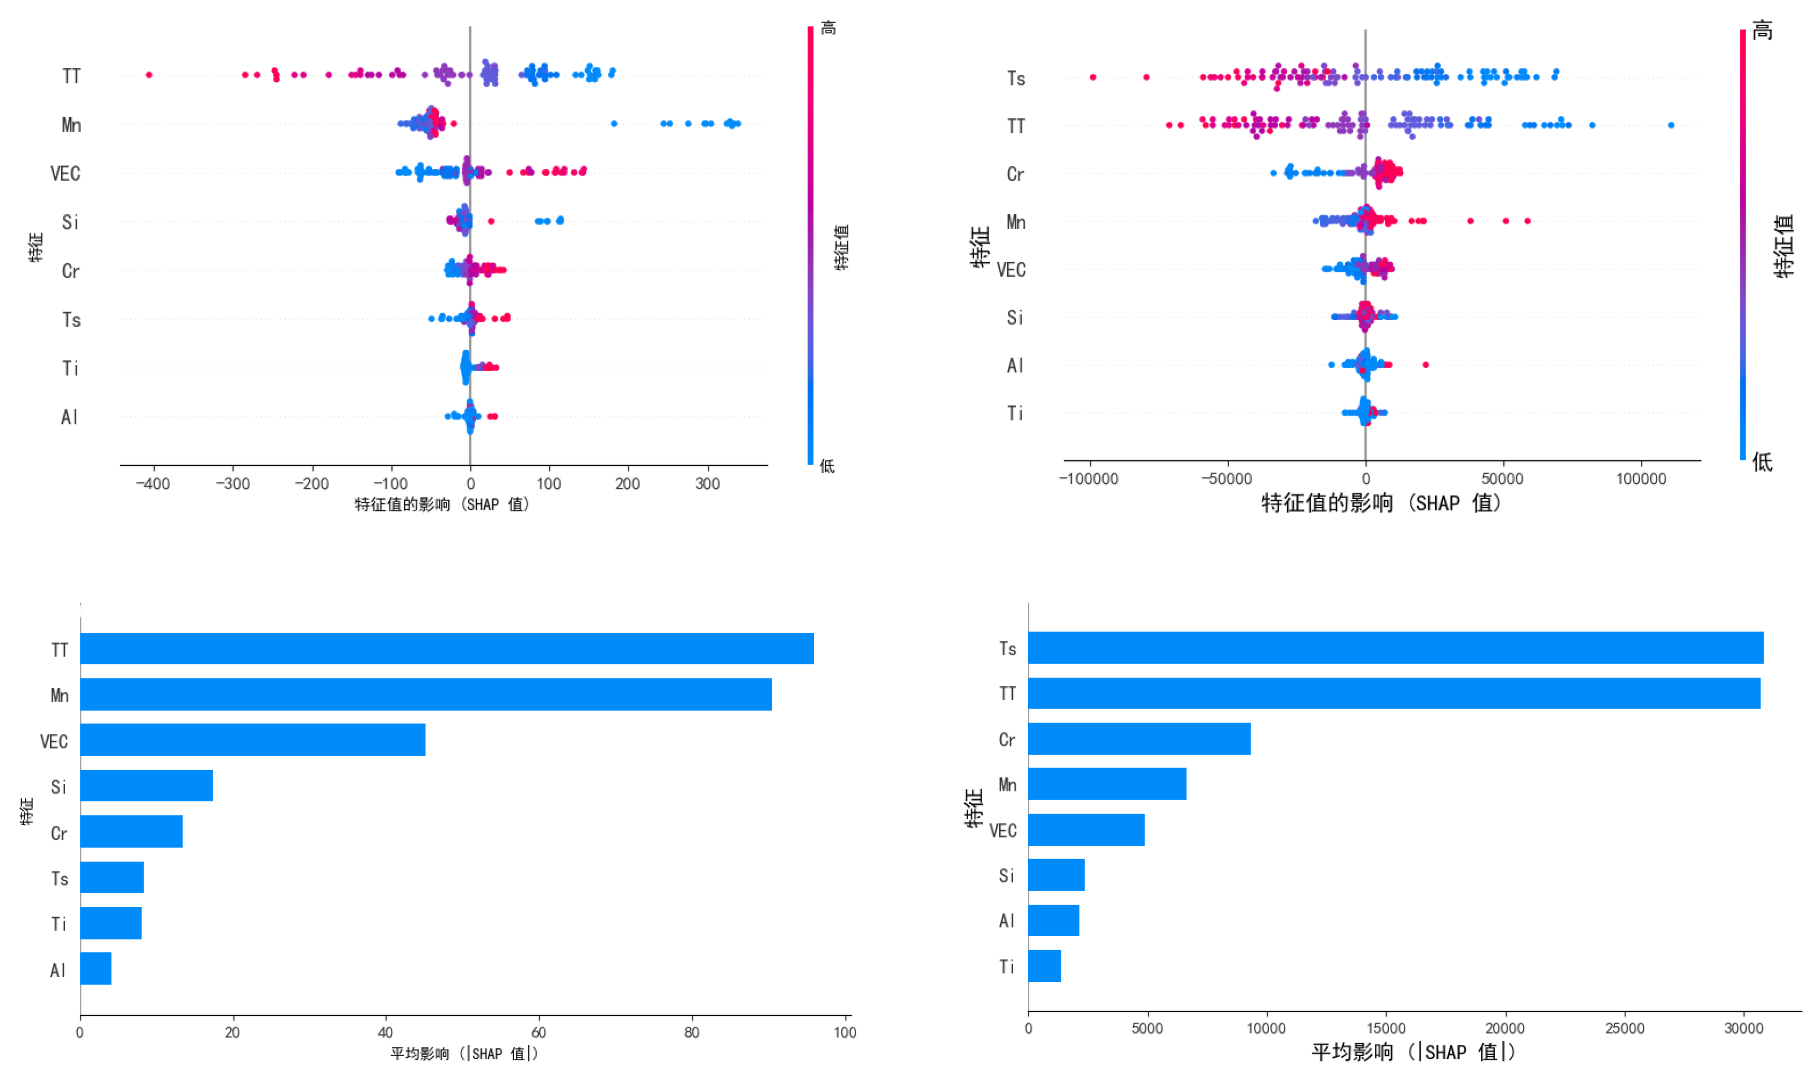

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 直接列出 4 个图像文件的路径
image_files = [
   r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_summary_plot_new1.png',
   r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_summary_plot_new1.png',
   r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_bar_plot_new1.png',
   r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_bar_plot_new1.png'
]

# 创建 2 行 2 列的布局
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 字母标签列表
labels = ['(a)', '(b)', '(c)', '(d)']

# 使用 font_manager 加载 Times New Roman 字体
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\times.ttf')  # 修改为您的字体文件路径

# 遍历每个图片文件
for index, image_path in enumerate(image_files):
    # 计算当前的行列
    row = index // 2
    col = index % 2
    
    # 读取当前类对应的图像文件
    img = plt.imread(image_path)
    
    # 在子图中显示图片
    axes[row, col].imshow(img)
    axes[row, col].axis('off')  # 隐藏坐标轴

    # 在左上角添加字母标签
    axes[row, col].text(0.05, 0.95, labels[index], fontsize=20, color='white', weight='bold', 
                        transform=axes[row, col].transAxes, fontproperties=prop)

# 隐藏多余的子图（如果有）
for j in range(len(image_files), 4):
    axes[j // 2, j % 2].axis('off')

# 调整图像之间的间距
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)

# 保存图像
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\2总shap.png', bbox_inches='tight')

# 显示图像
plt.show()

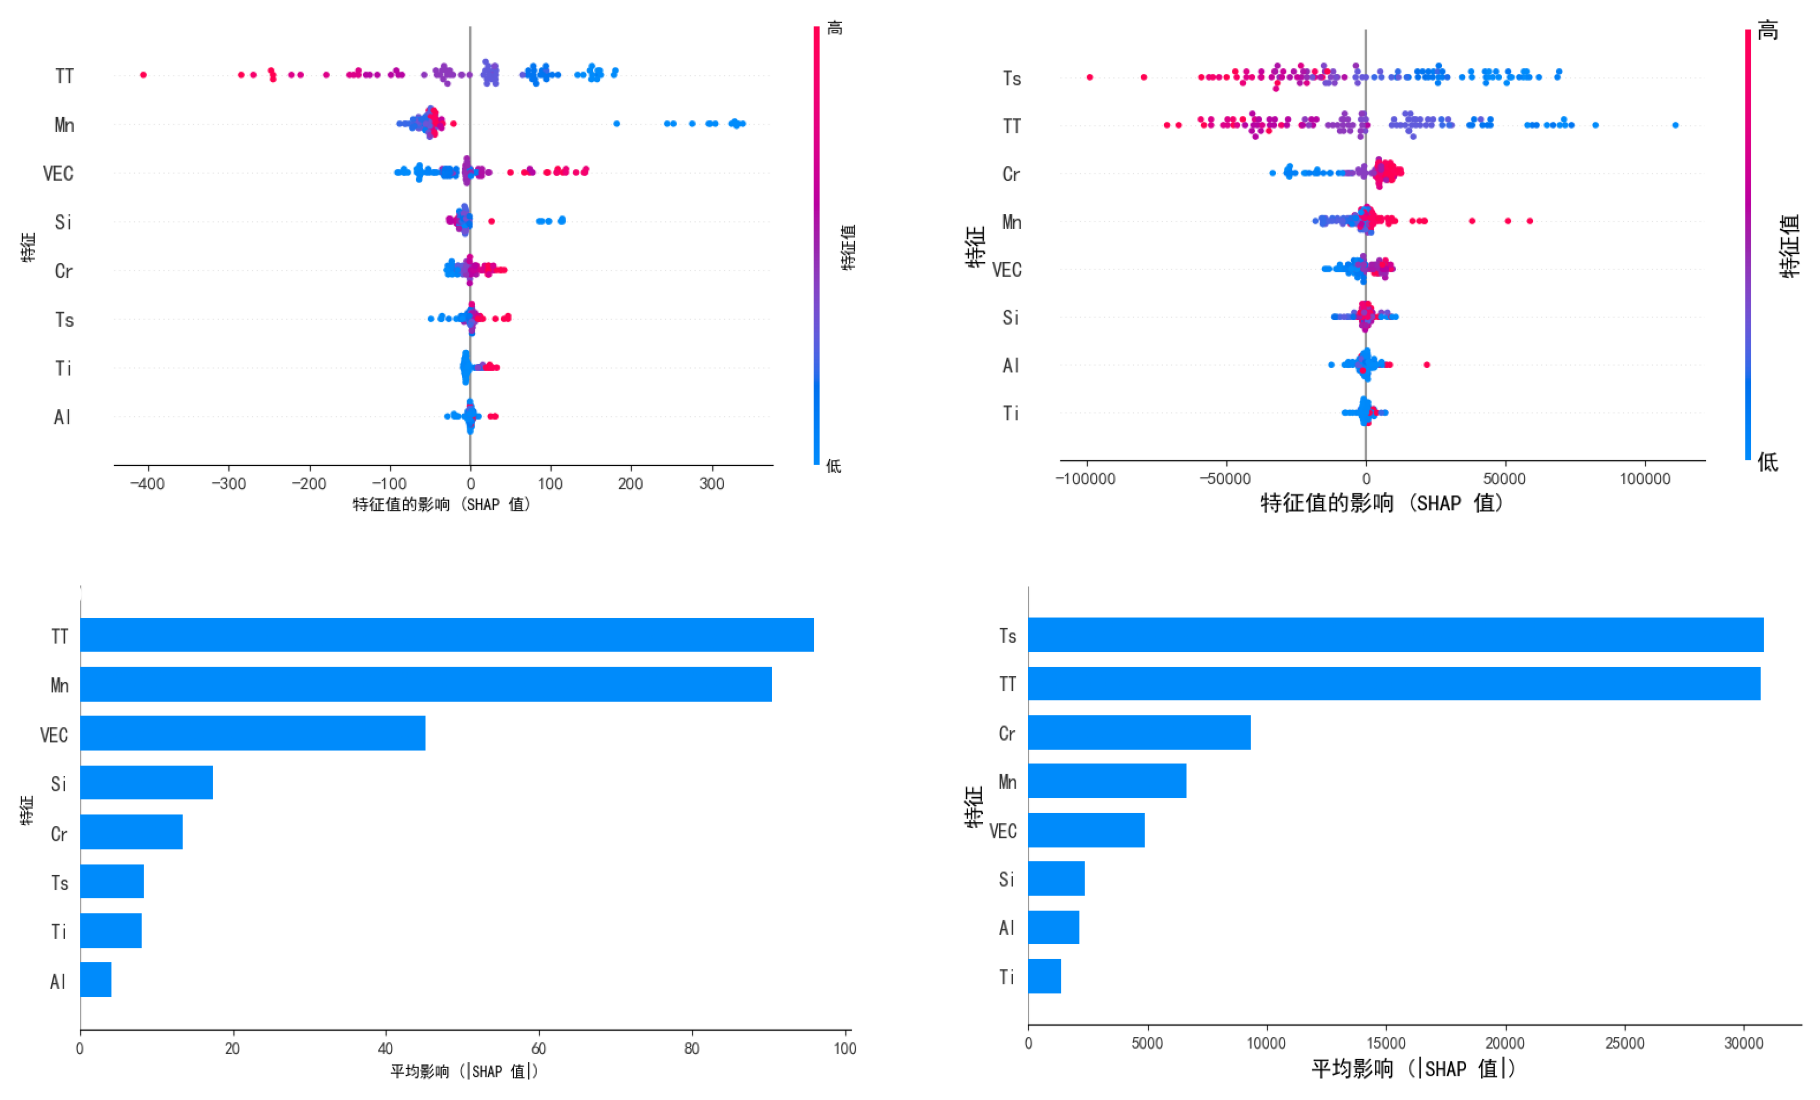

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 直接列出 4 个图像文件的路径
image_files = [
    r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_summary_plot_new1.png',
    r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_summary_plot_new1.png',
    r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_bar_plot_new1.png',
    r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_bar_plot_new1.png'
]

# 创建 2 行 2 列的布局
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 字母标签列表
labels = ['(a)', '(b)', '(c)', '(d)']

# 使用 font_manager 加载 Times New Roman 字体
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\times.ttf')  # 修改为您的字体文件路径

# 遍历每个图片文件
for index, image_path in enumerate(image_files):
    # 计算当前的行列
    row = index // 2
    col = index % 2

    # 读取当前类对应的图像文件
    img = plt.imread(image_path)

    # 在子图中显示图片
    axes[row, col].imshow(img, aspect='auto')  # 设置 aspect='auto' 以自动调整图像显示比例
    axes[row, col].axis('off')  # 隐藏坐标轴

    # 在左上角添加字母标签
    axes[row, col].text(0.05, 0.95, labels[index], fontsize=20, color='white', weight='bold',
                        transform=axes[row, col].transAxes, fontproperties=prop)

# 隐藏多余的子图（如果有）
for j in range(len(image_files), 4):
    axes[j // 2, j % 2].axis('off')

# 调整图像之间的间距
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)

# 保存图像
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\2总shap.png', bbox_inches='tight')

# 显示图像
plt.show()


In [5]:
# 第一组代码
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 读取训练数据
train_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2train_data新.xlsx')
train_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)  # 删除空缺值

# 读取测试数据
test_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')
test_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)
x_train = train_data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_train = train_data['Tensile Strength(Mpa)']
x_test = test_data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_test = test_data['Tensile Strength(Mpa)']

# 1. 加载保存的模型
model = joblib.load('model_optimalsameTR.pkl')

# 2. 读取Excel数据
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR10.85test_data新.xlsx')

# 3. 选择特征和目标列
x_new = data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_new = data['Time to Rupture(h)']  # 目标变量

# 4. 进行SHAP分析
explainer = shap.Explainer(model, x_new)
shap_values = explainer(x_new)

# 设置字体属性
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\simhei.ttf')  # 使用黑体字体文件路径
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
# 设置 Matplotlib 的负号显示方式
mpl.rcParams['axes.unicode_minus'] = False

# 1. 特征重要性图
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, x_new, show=False)
plt.xlabel('特征值的影响 (SHAP 值)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题

# 获取当前图形的颜色条对象
colorbar = plt.gcf().axes[-1]

# 修改颜色条的标签
colorbar.set_ylabel('特征值', fontproperties=prop)
colorbar.set_yticklabels(['低', '高'], fontproperties=prop)

plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_summary_plot_new1.png', bbox_inches='tight', dpi=300)  # 保存特征重要性图
plt.close()

# 2. SHAP值的绝对值条形图
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, x_new, plot_type='bar', show=False)
plt.xlabel('平均影响 (|SHAP 值|)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_bar_plot_new1.png', bbox_inches='tight', dpi=300)  # 保存条形图
plt.close()

# 第二组代码
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 读取训练数据
train_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2train_data新.xlsx')
train_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)  # 删除空缺值

# 读取测试数据
test_data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')
test_data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)
x_train = train_data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_train = train_data['Tensile Strength(Mpa)']
x_test = test_data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_test = test_data['Tensile Strength(Mpa)']

# 1. 加载保存的模型
model = joblib.load('model_optimalsameTs.pkl')

# 2. 读取Excel数据
data = pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TF-IDF2test_data新.xlsx')

# 3. 选择特征和目标列
x_new = data[['Si', 'Mn', 'Al', 'Cr', 'Ti', 'VEC', 'TT', 'Ts']]
y_new = data['Tensile Strength(Mpa)']  # 目标变量

# 4. 进行SHAP分析
explainer = shap.Explainer(model, x_new)
shap_values = explainer(x_new)

# 设置字体属性
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\simhei.ttf')  # 使用黑体字体文件路径
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
# 设置 Matplotlib 的负号显示方式
mpl.rcParams['axes.unicode_minus'] = False

# 1. 特征重要性图
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, x_new, show=False)
plt.xlabel('特征值的影响 (SHAP 值)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题

# 获取当前图形的颜色条对象
colorbar = plt.gcf().axes[-1]

# 修改颜色条的标签
colorbar.set_ylabel('特征值', fontproperties=prop)
colorbar.set_yticklabels(['低', '高'], fontproperties=prop)

plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_summary_plot_new1.png', bbox_inches='tight', dpi=300)  # 保存特征重要性图
plt.close()

# 2. SHAP值的绝对值条形图
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, x_new, plot_type='bar', show=False)
plt.xlabel('平均影响 (|SHAP 值|)', fontproperties=prop)
plt.ylabel('特征', fontproperties=prop)
plt.title('')  # 移除标题
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_bar_plot_new1.png', bbox_inches='tight', dpi=300)  # 保存条形图
plt.close()

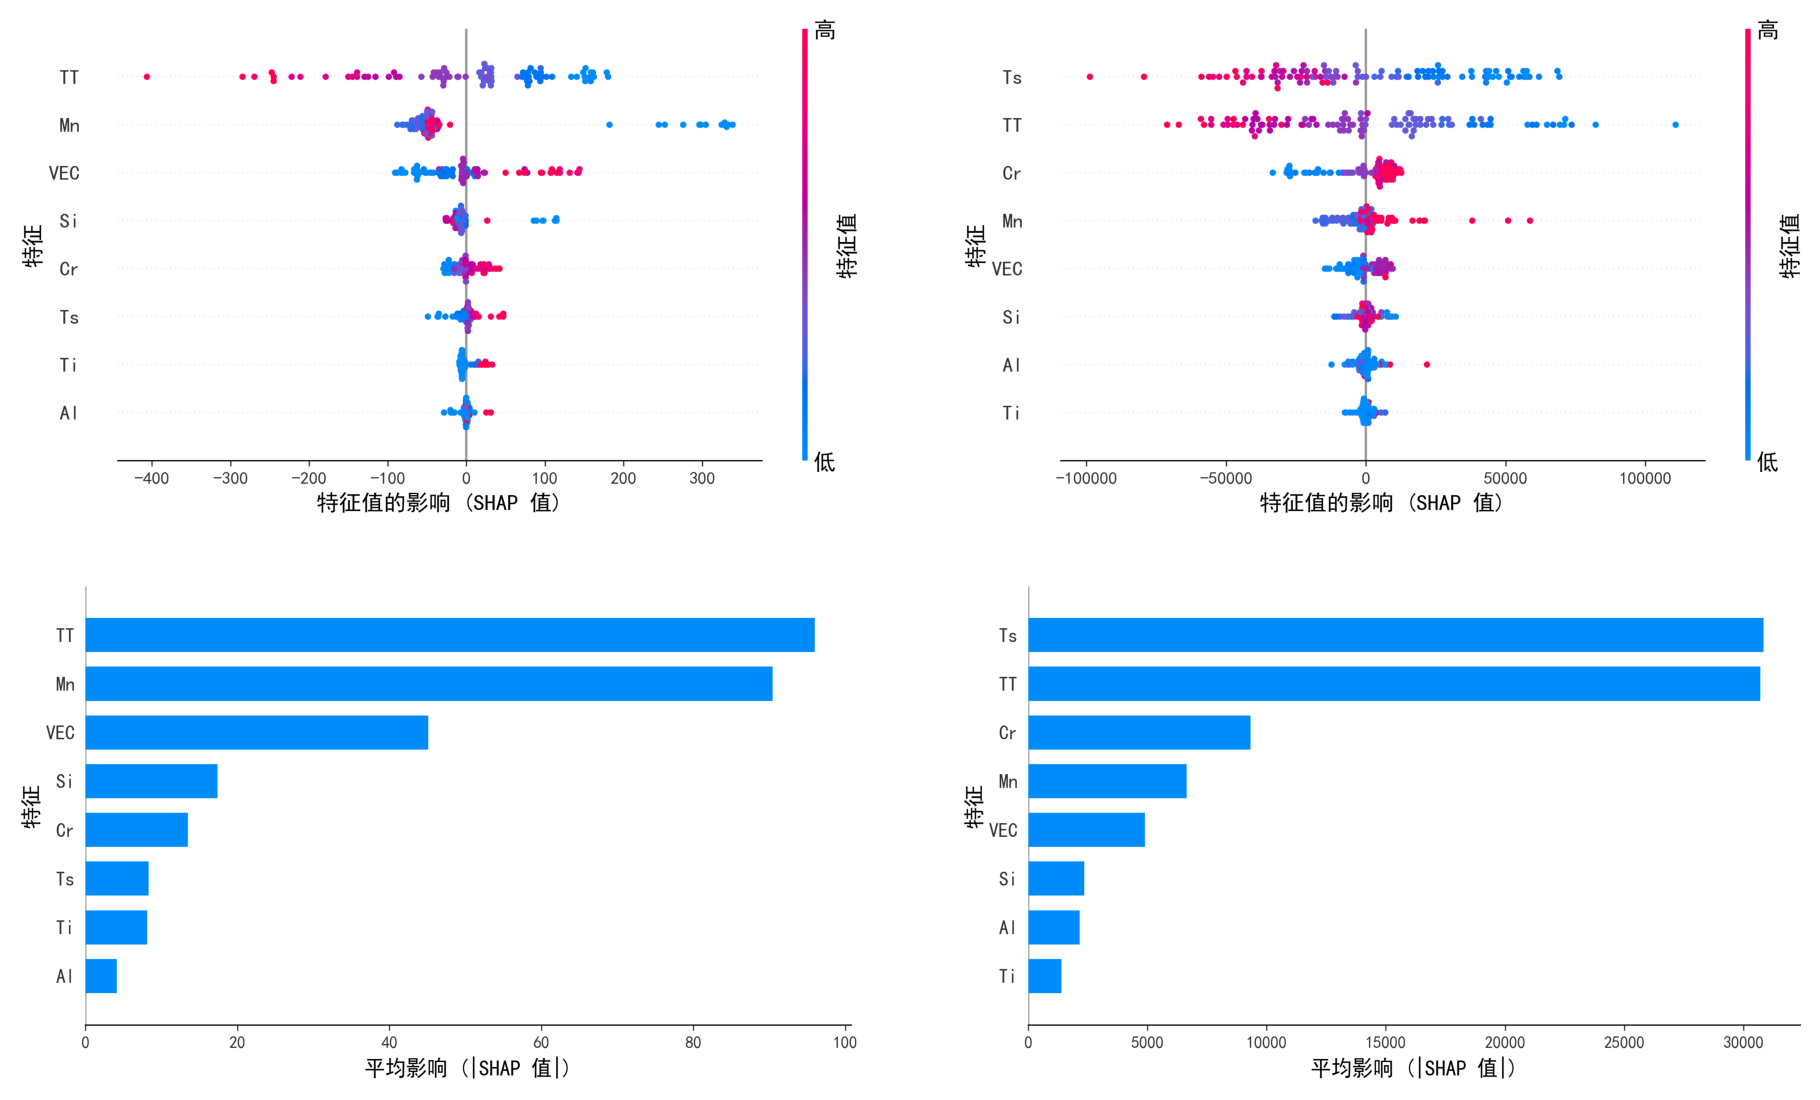

In [6]:
# 最终合并代码
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 直接列出 4 个图像文件的路径
image_files = [
    r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_summary_plot_new1.png',
    r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_summary_plot_new1.png',
    r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\shap_bar_plot_new1.png',
    r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\TR_shap_bar_plot_new1.png'
]

# 创建 2 行 2 列的布局
fig, axes = plt.subplots(2, 2, figsize=(20, 12), gridspec_kw={'width_ratios': [1, 1], 'height_ratios': [1, 1]})

# 字母标签列表
labels = ['(a)', '(b)', '(c)', '(d)']

# 使用 font_manager 加载 Times New Roman 字体
prop = fm.FontProperties(fname=r'C:\Windows\Fonts\times.ttf')  # 修改为您的字体文件路径

# 遍历每个图片文件
for index, image_path in enumerate(image_files):
    # 计算当前的行列
    row = index // 2
    col = index % 2
    
    # 读取当前类对应的图像文件
    img = plt.imread(image_path)
    
    # 在子图中显示图片
    axes[row, col].imshow(img, aspect='auto')  # 设置 aspect='auto' 以自动调整图像显示比例
    axes[row, col].axis('off')  # 隐藏坐标轴

    # 在左上角添加字母标签
    axes[row, col].text(0.05, 0.95, labels[index], fontsize=20, color='white', weight='bold', 
                        transform=axes[row, col].transAxes, fontproperties=prop)

# 调整图像之间的间距
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)

# 保存图像
plt.savefig(r'D:\creep rupture\添加高温测试和高应力\pearson+RFE+特征重要性排序\2总shap.png', bbox_inches='tight', dpi=300)

# 显示图像
plt.show()